In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import os
import sys
import pickle
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/')
import spk_feat_cluster_comp_analysis
importlib.reload(spk_feat_cluster_comp_analysis)
from spk_feat_cluster_comp_analysis import (
    plot_lfp_metrics_low_vs_high,
    plot_lfp_block_comparison,
    plot_lfp_avg_psd_per_feature,
    analyze_lfp_around_transitions,
)
import config

CLUSTER_PKL_DIR = config.SPE1_PICKLE_ROOT + '/cluster_pickles/'
LFP_NPY_DIR     = os.path.join(config.SPE1_DATA_ROOT, 'filt_lfp_recordings')

In [2]:
df_transitions = pd.read_pickle(CLUSTER_PKL_DIR + 'temporal_transitions.pkl')
peri_results   = pickle.load(open(CLUSTER_PKL_DIR + 'lfp_peri_transition_results.pkl', 'rb'))

# peri_results keys: (cell_id, feat, transition_index)
used_pairs = {(k[0], k[1]) for k, v in peri_results.items() if len(v) == 3}
print(f'{len(df_transitions.groupby(["cell_id","spike_feature"]))} detected transitions')
print(f'{len(peri_results)} transition LFP entries, {len(used_pairs)} unique cell×feat pairs')

46 detected transitions
52 transition LFP entries, 42 unique cell×feat pairs


  [mean_amp|peak_width] n=11 p=0.0322 *
  [mean_amp|peak_amp] n=14 p=0.1353 ns
  [mean_amp|exp_lambda] n=7 p=0.4688 ns
  [mean_amp|peak_sharpness] n=6 p=1.0000 ns
  [mean_amp|log_isi] n=6 p=0.2188 ns
  [std_amp|peak_width] n=11 p=0.7646 ns
  [std_amp|peak_amp] n=14 p=0.2676 ns
  [std_amp|exp_lambda] n=7 p=0.2188 ns
  [std_amp|peak_sharpness] n=6 p=0.8438 ns
  [std_amp|log_isi] n=6 p=0.5625 ns
  [exponent|peak_width] n=11 p=0.5195 ns
  [exponent|peak_amp] n=14 p=0.1531 ns
  [exponent|exp_lambda] n=7 p=0.0781 ns
  [exponent|peak_sharpness] n=6 p=0.8438 ns
  [exponent|log_isi] n=6 p=1.0000 ns
  [offset|peak_width] n=11 p=0.9658 ns
  [offset|peak_amp] n=14 p=0.0676 ns
  [offset|exp_lambda] n=7 p=0.1562 ns
  [offset|peak_sharpness] n=6 p=0.5625 ns
  [offset|log_isi] n=6 p=0.5625 ns
  [theta_auc|peak_width] n=11 p=0.2845 ns
  [theta_auc|peak_amp] n=14 p=0.9515 ns
  [theta_auc|exp_lambda] n=7 p=0.0156 *
  [theta_auc|peak_sharpness] n=6 p=0.8927 ns
  [theta_auc|log_isi] n=6 p=0.4375 ns
  [tota

/Users/blancamartin/opt/anaconda3/envs/spikeparam/lib/python3.11/site-packages/scipy/stats/_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/Users/blancamartin/opt/anaconda3/envs/spikeparam/lib/python3.11/site-packages/scipy/stats/_morestats.py:3428: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")


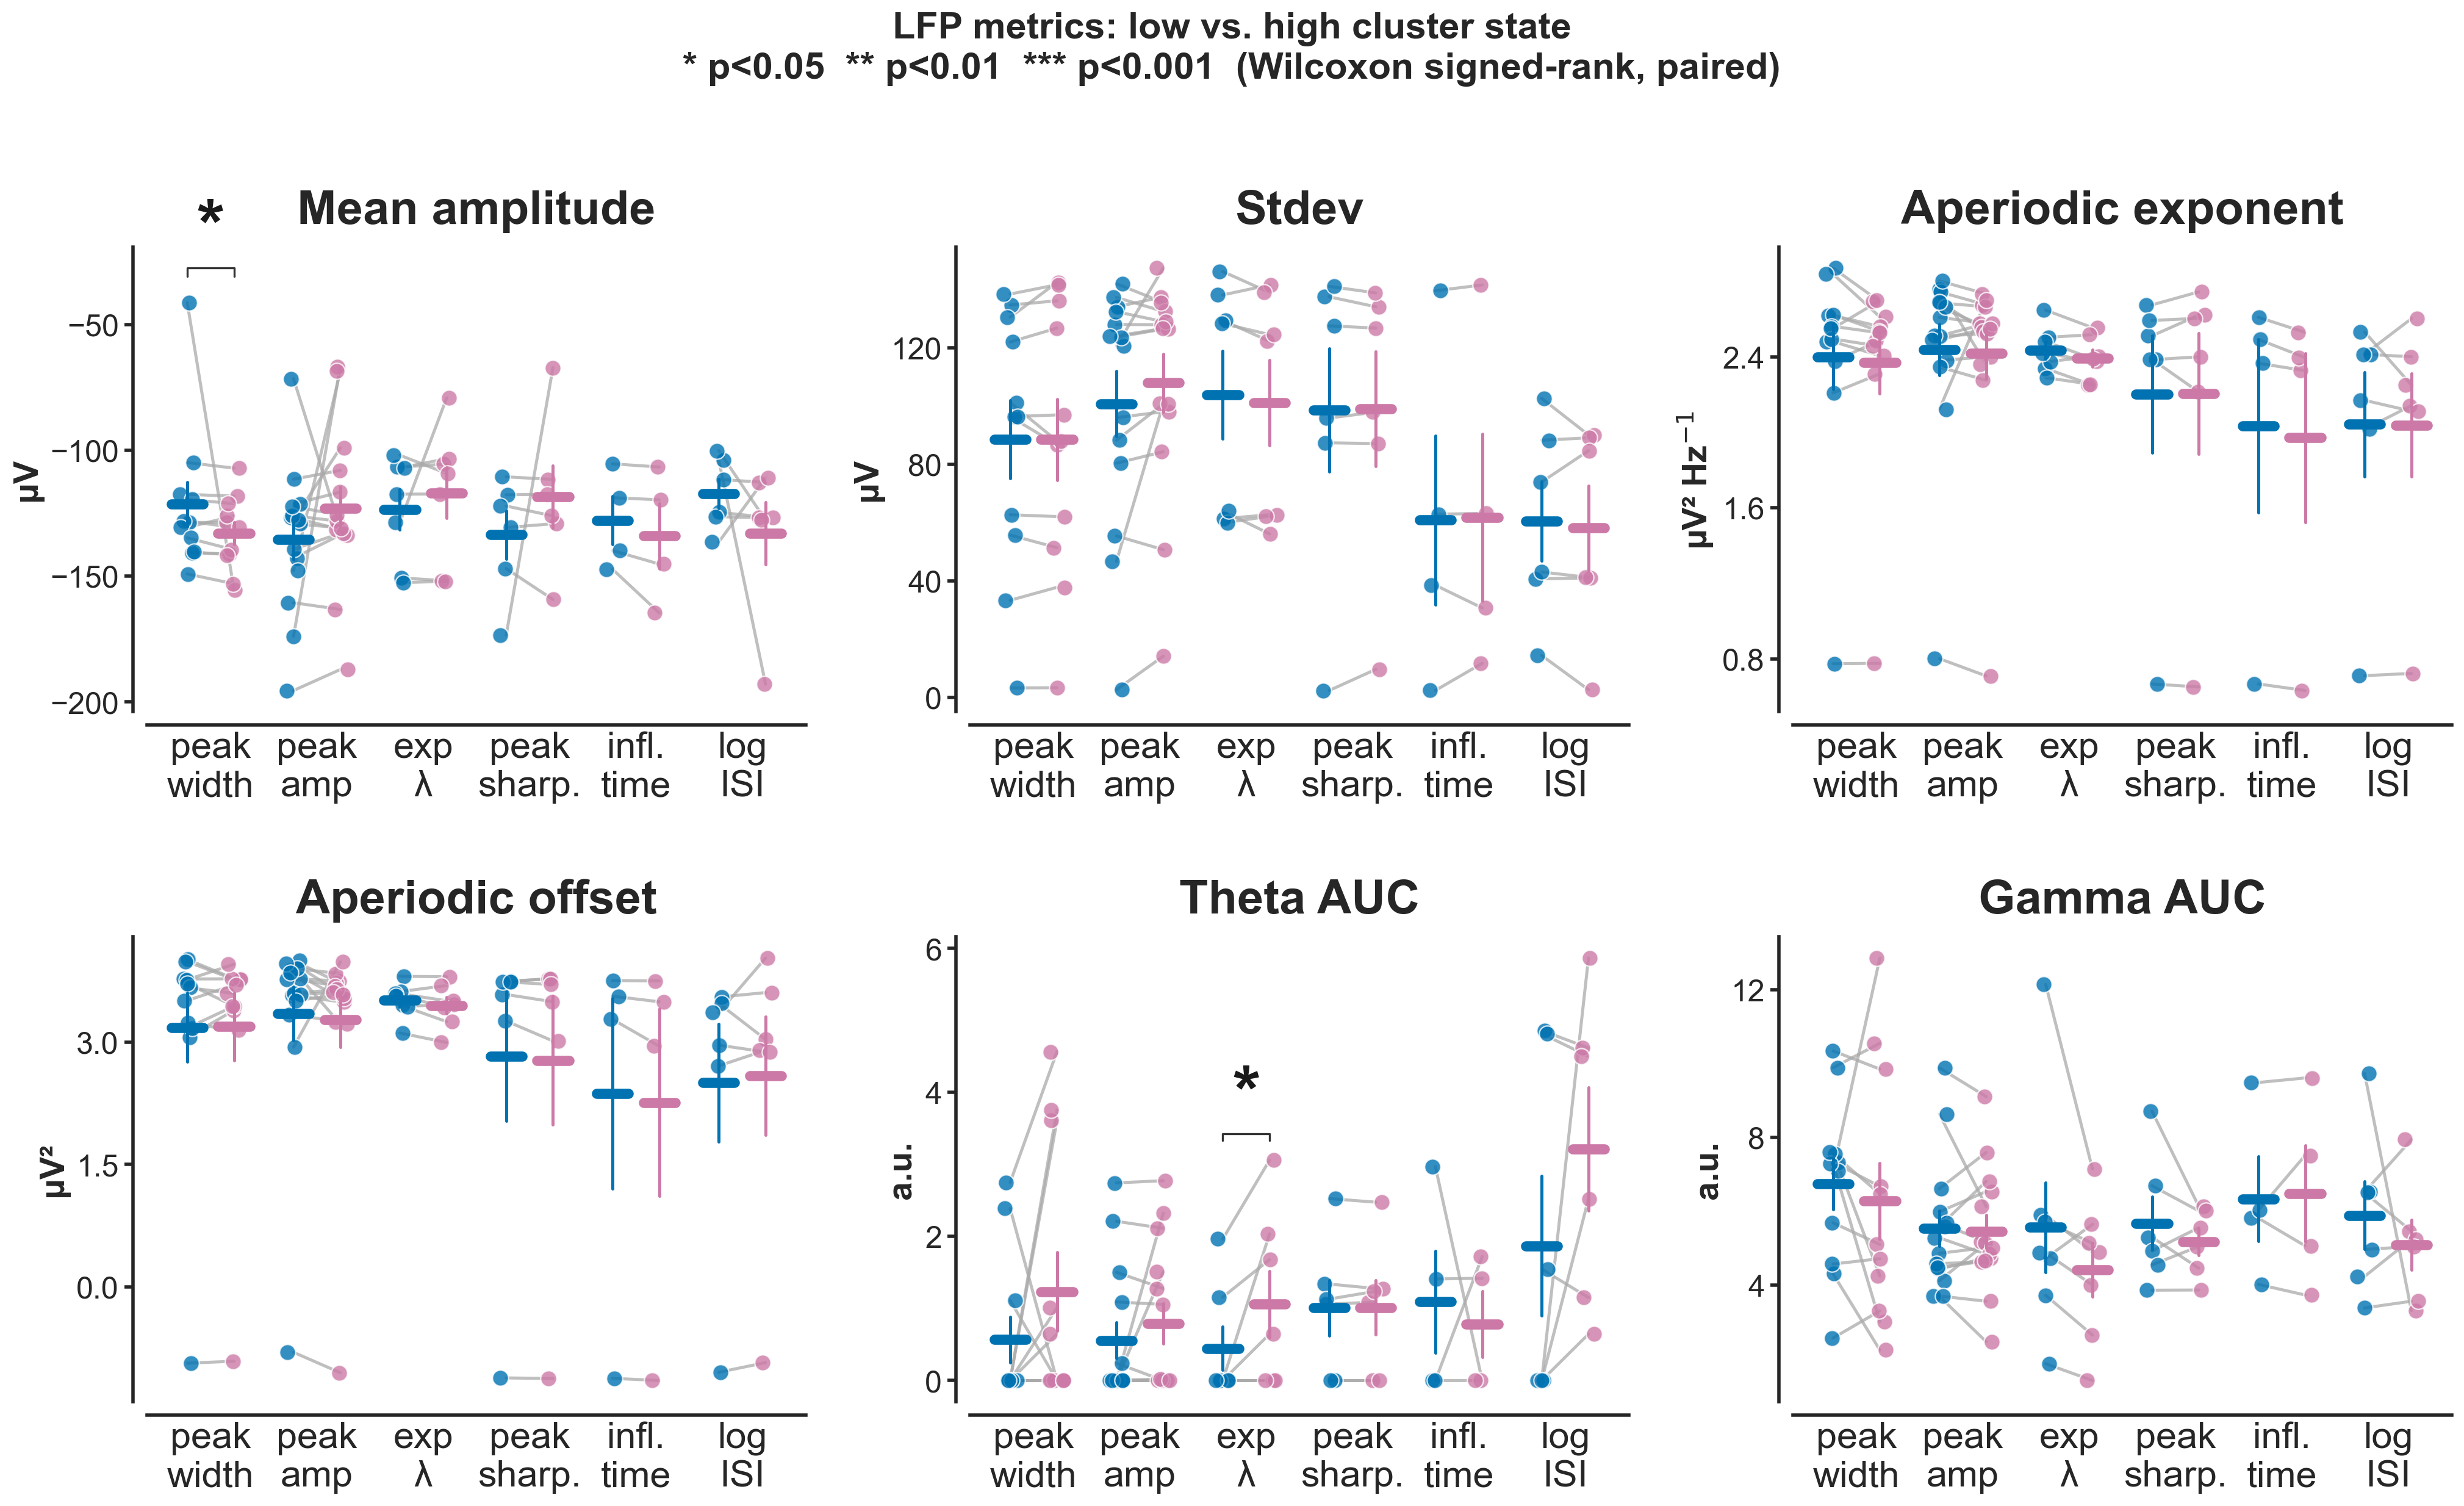

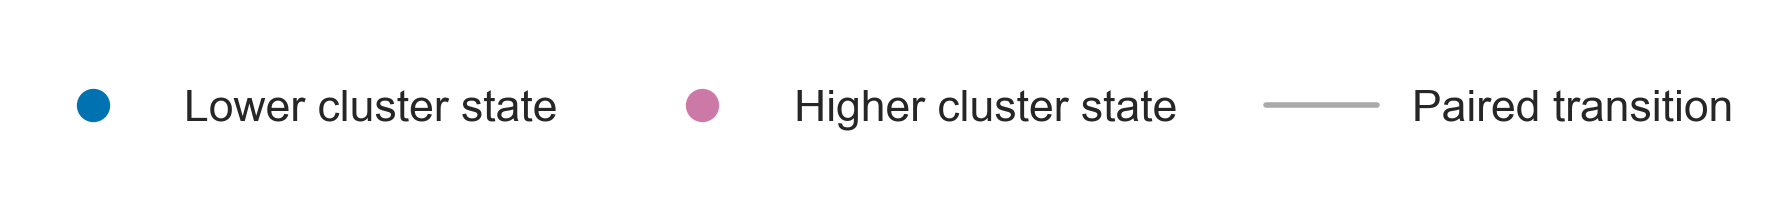

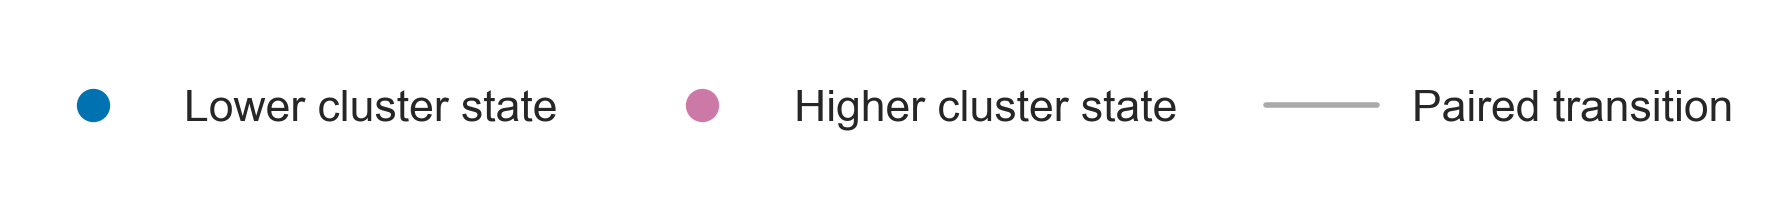

In [3]:
# Shared figsize for all LFP panels (dot plot + PSD must match exactly)
_LFP_KEYS = ['mean_amp', 'std_amp', 'exponent', 'offset', 'theta_auc', 'total_gamma_auc']
_SHARED_FW = (1.2 + 0.95 * 6) * 3   # 20.7 in
_SHARED_FH = 6.2 * 2                 # 12.4 in

# Panel A: LFP scalar metrics — low vs high cluster state per spike feature
fig_met, fig_met_leg = plot_lfp_metrics_low_vs_high(
    peri_results, df_transitions, lfp_keys=_LFP_KEYS,
    figsize=(_SHARED_FW, _SHARED_FH),
)
plt.show()
display(fig_met_leg)

  [peak_width] n=11  θ p=0.1475 (adj 0.1475)  γ p=0.2061 (adj 0.2061)  ns
  [peak_amp] n=14  θ p=0.0785 (adj 0.0785)  γ p=0.1531 (adj 0.1531)  ns
  [exp_lambda] n=7  θ p=0.1094 (adj 0.1094)  γ p=0.5781 (adj 0.5781)  ns
  [peak_sharpness] n=6  θ p=0.0625 (adj 0.0625)  γ p=0.1562 (adj 0.1562)  ns
  [inflection_time] n=4  θ p=0.8750 (adj 0.8750)  γ p=0.8750 (adj 0.8750)  ns
  [log_isi] n=6  θ p=0.2188 (adj 0.2188)  γ p=0.0625 (adj 0.0625)  ns


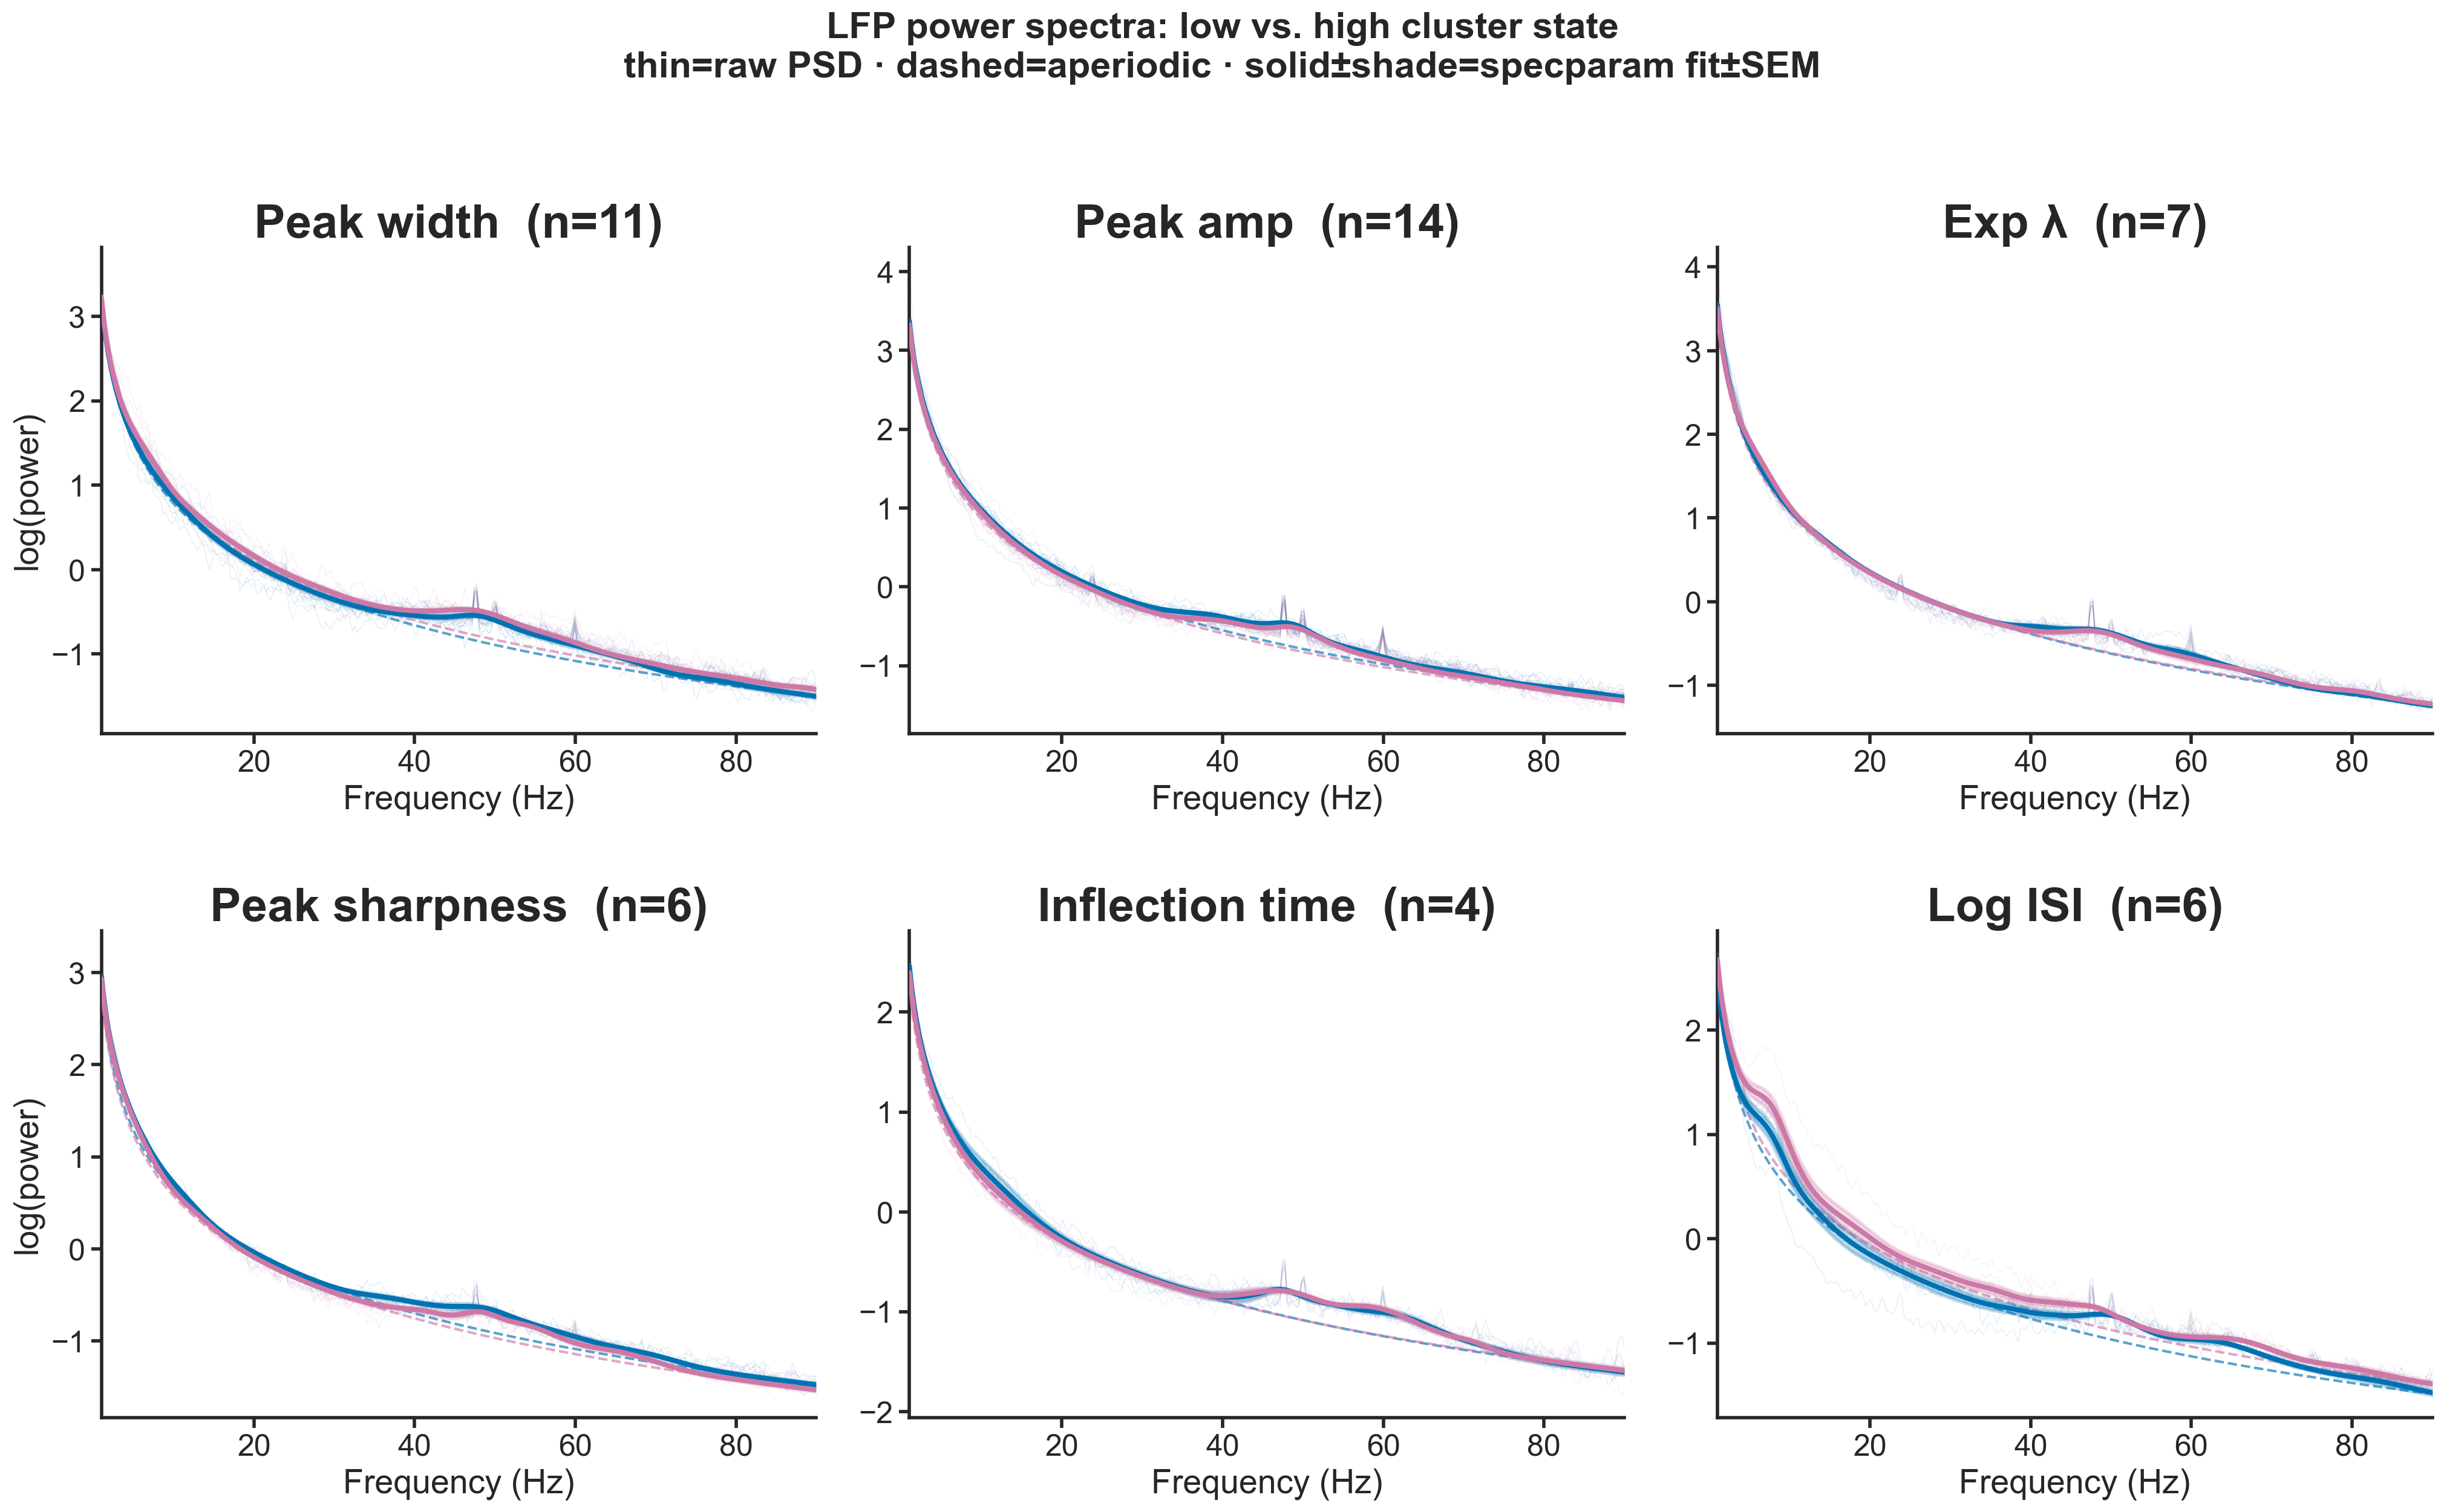

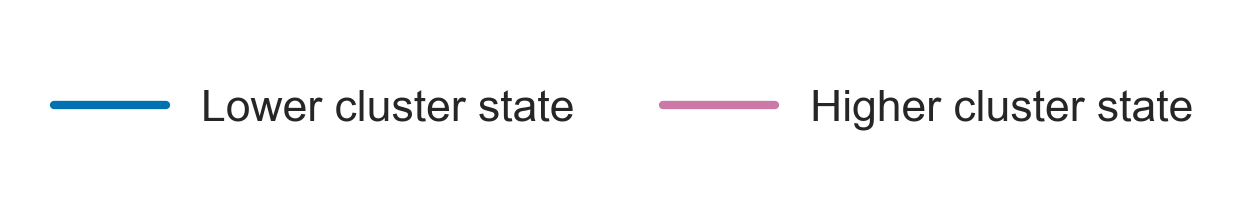

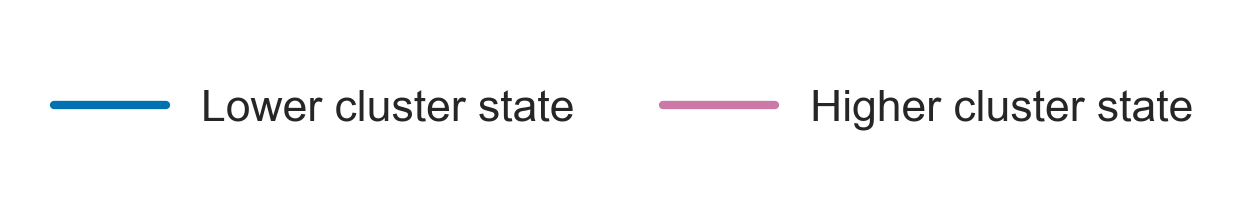

In [4]:
# Panel B: LFP spectra — low vs high cluster state per spike feature
fig_psd, fig_psd_leg = plot_lfp_avg_psd_per_feature(
    peri_results, df_transitions,
    figsize=(_SHARED_FW, _SHARED_FH),
)
plt.show()
display(fig_psd_leg)

In [5]:
ORD = {'low':0,'mid':1,'high':2,'Low':0,'Mid':1,'High':2}

rows = []
for (cid, feat, t_idx), blocks in peri_results.items():
    bmap = {b['label']: b for b in blocks}
    if 'pre' not in bmap or 'post' not in bmap:
        continue
    tr = df_transitions[(df_transitions.cell_id==cid) &
                        (df_transitions.spike_feature==feat) &
                        (df_transitions.transition_index==t_idx)]
    if tr.empty: continue
    before = ORD.get(str(tr.iloc[0]['cluster_before']).lower(), 1)
    after  = ORD.get(str(tr.iloc[0]['cluster_after']).lower(),  1)
    sign   = 1 if after > before else -1
    d_gamma = sign * (bmap['post']['total_gamma_auc'] - bmap['pre']['total_gamma_auc'])
    rows.append(dict(cell_id=cid, feat=feat, t_idx=t_idx, sign=sign,
                     d_gamma=d_gamma, abs_d=abs(d_gamma)))

df_top = pd.DataFrame(rows).sort_values('abs_d', ascending=False)
print('Top transitions by |sign-corrected Δ total gamma AUC|:')
print(df_top.head(6)[['cell_id','feat','t_idx','sign','d_gamma']].round(3).to_string())

Top transitions by |sign-corrected Δ total gamma AUC|:
   cell_id            feat  t_idx  sign  d_gamma
21     c24         log_isi      0    -1   -6.428
25     c25      peak_width      0     1    5.771
22     c25      exp_lambda      1    -1   -5.003
31     c35      peak_width      0     1   -4.279
43      c5      peak_width      2     1   -3.360
2       c1  peak_sharpness      2    -1   -2.579



=== c24 | log_isi ===
  pre         R²=0.991  exp=2.603  θ=5.8677  sγ=3.3050  hγ=0.0000  totγ=3.3050  peaks=[CF=9.2Hz PW=0.700]
  post        R²=0.986  exp=2.414  θ=0.0000  sγ=5.0071  hγ=4.7262  totγ=9.7333  peaks=[CF=60.5Hz PW=0.404]


/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:5422: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  _bar_axes[1].legend(fontsize=13, frameon=False, loc='upper right')
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:5426: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=2.5, w_pad=2.0, h_pad=2.0)


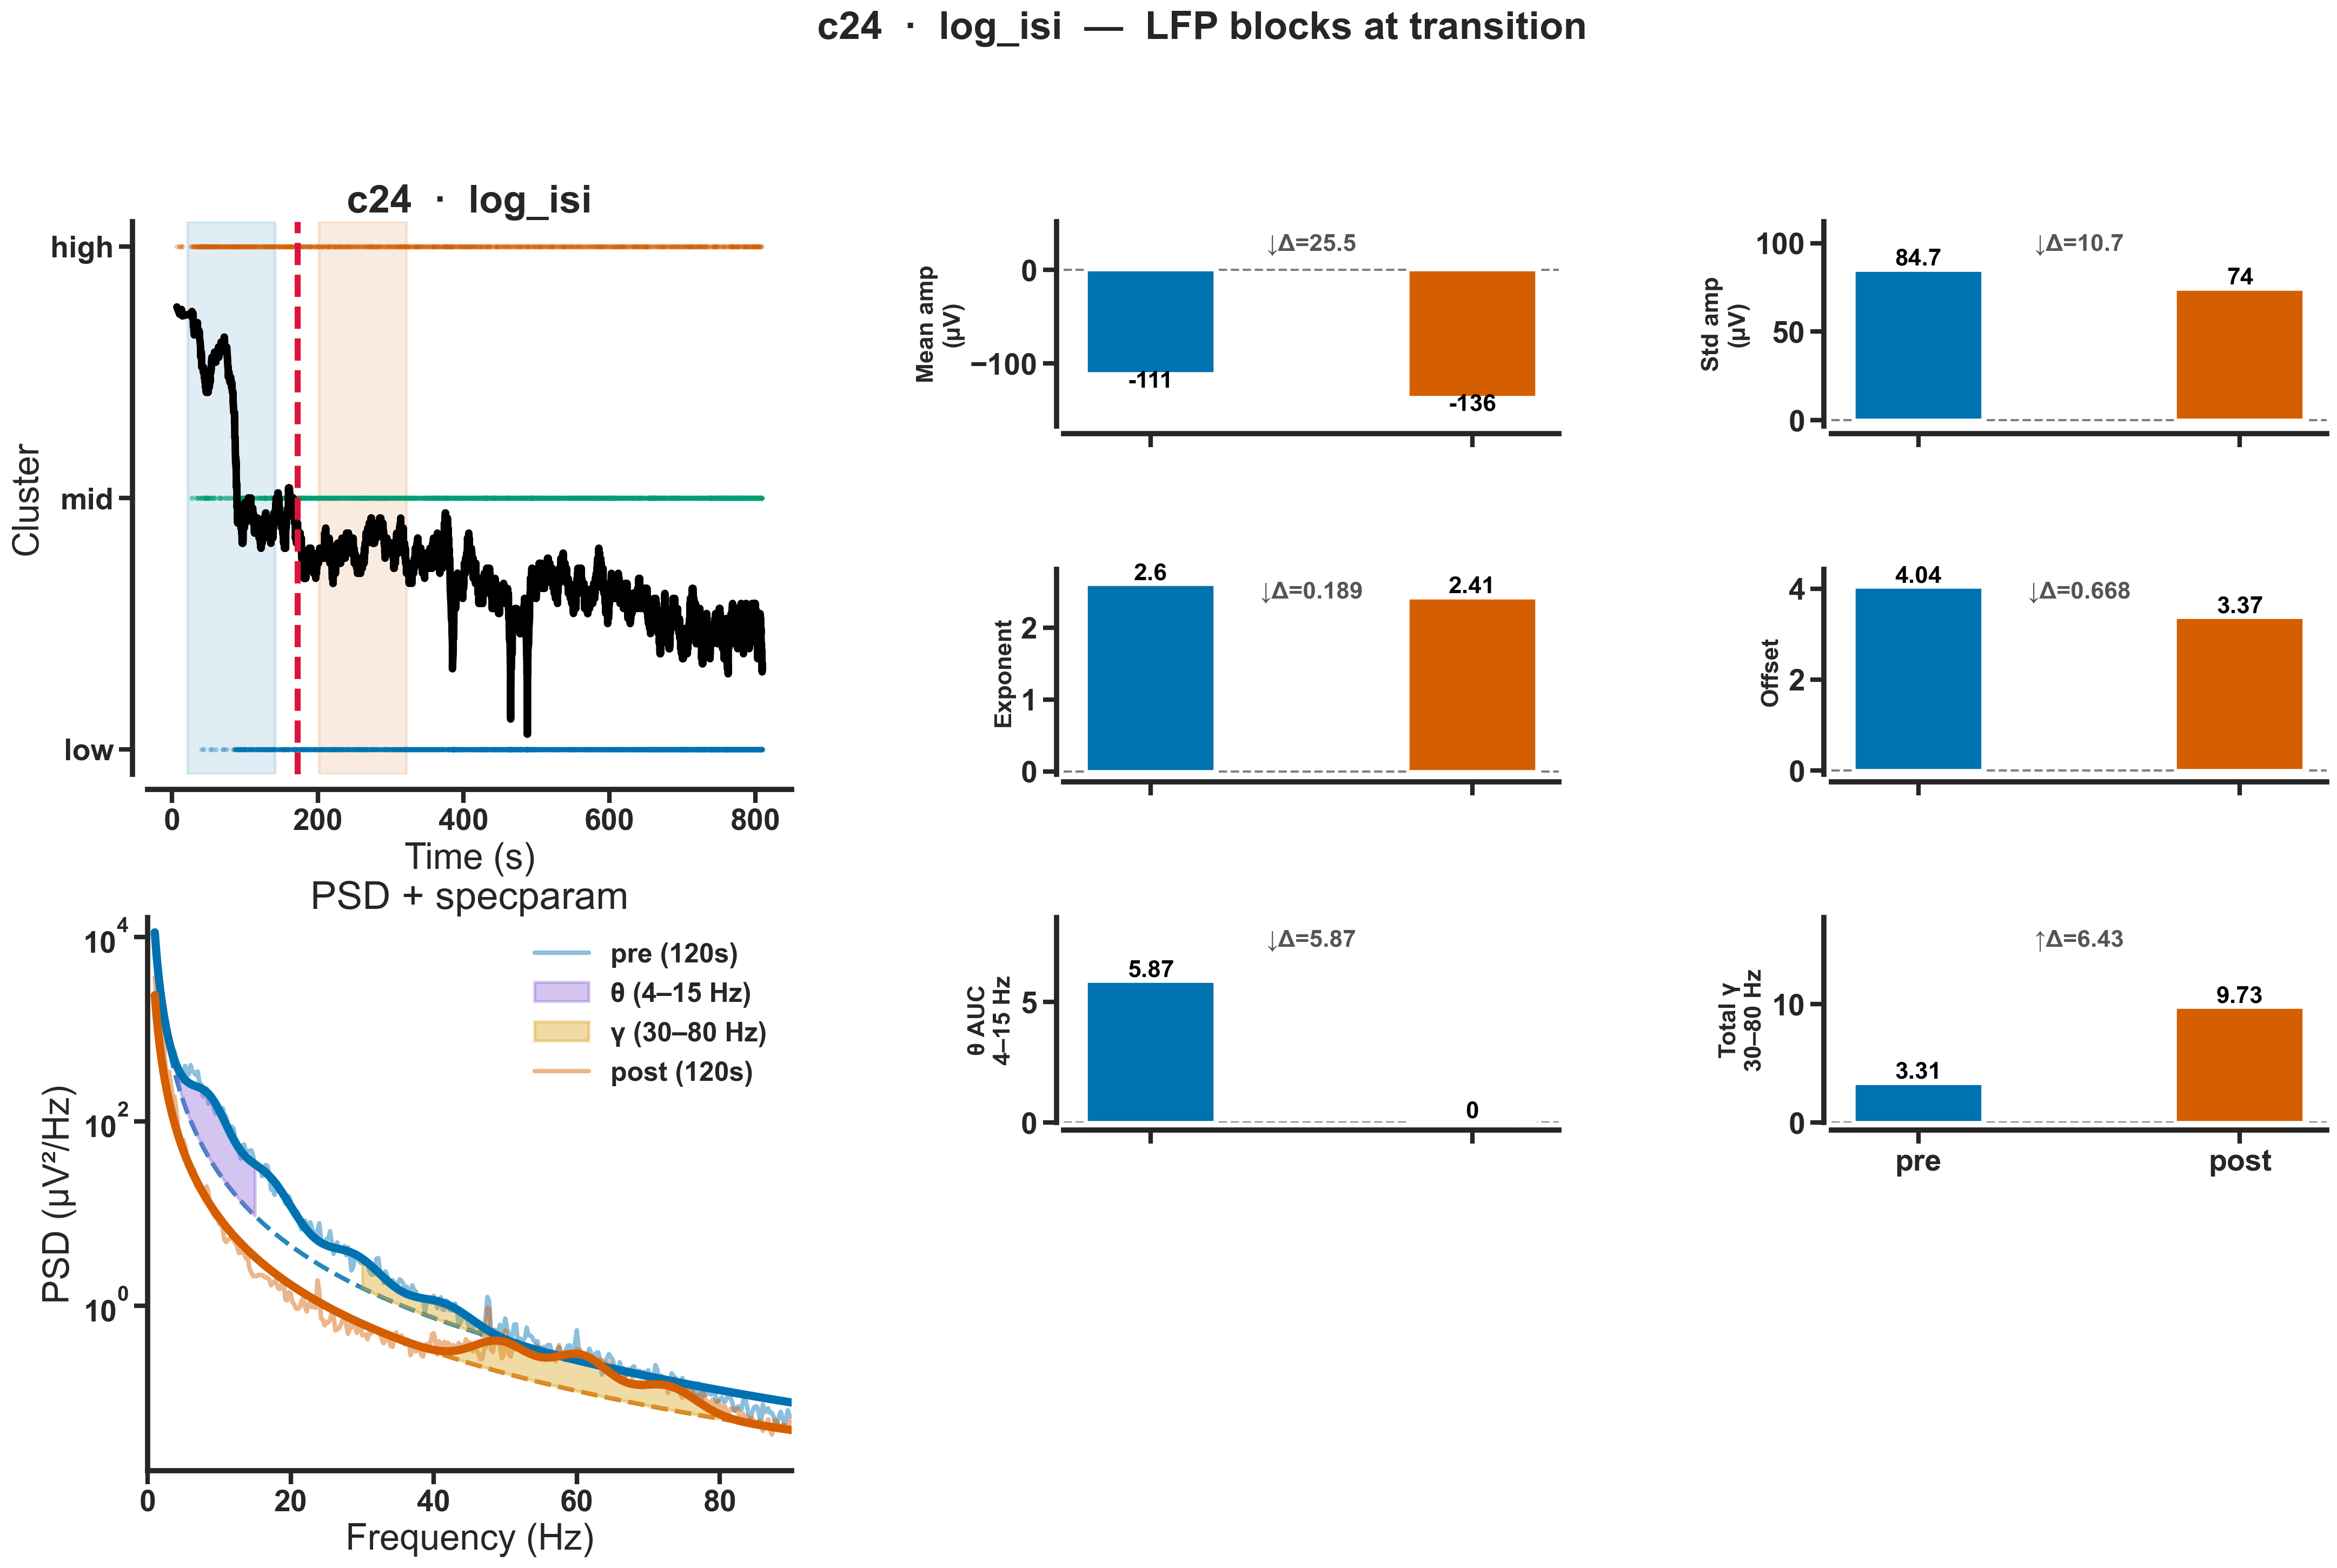


=== c25 | exp_lambda ===
  pre         R²=0.989  exp=2.251  θ=2.0358  sγ=3.4056  hγ=3.7408  totγ=7.1464  peaks=[CF=6.5Hz PW=0.281, CF=66.2Hz PW=0.392]
  post        R²=0.990  exp=2.338  θ=0.0000  sγ=6.9868  hγ=5.1626  totγ=12.1494  peaks=[CF=58.0Hz PW=0.594]


/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:5422: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  _bar_axes[1].legend(fontsize=13, frameon=False, loc='upper right')
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:5426: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=2.5, w_pad=2.0, h_pad=2.0)


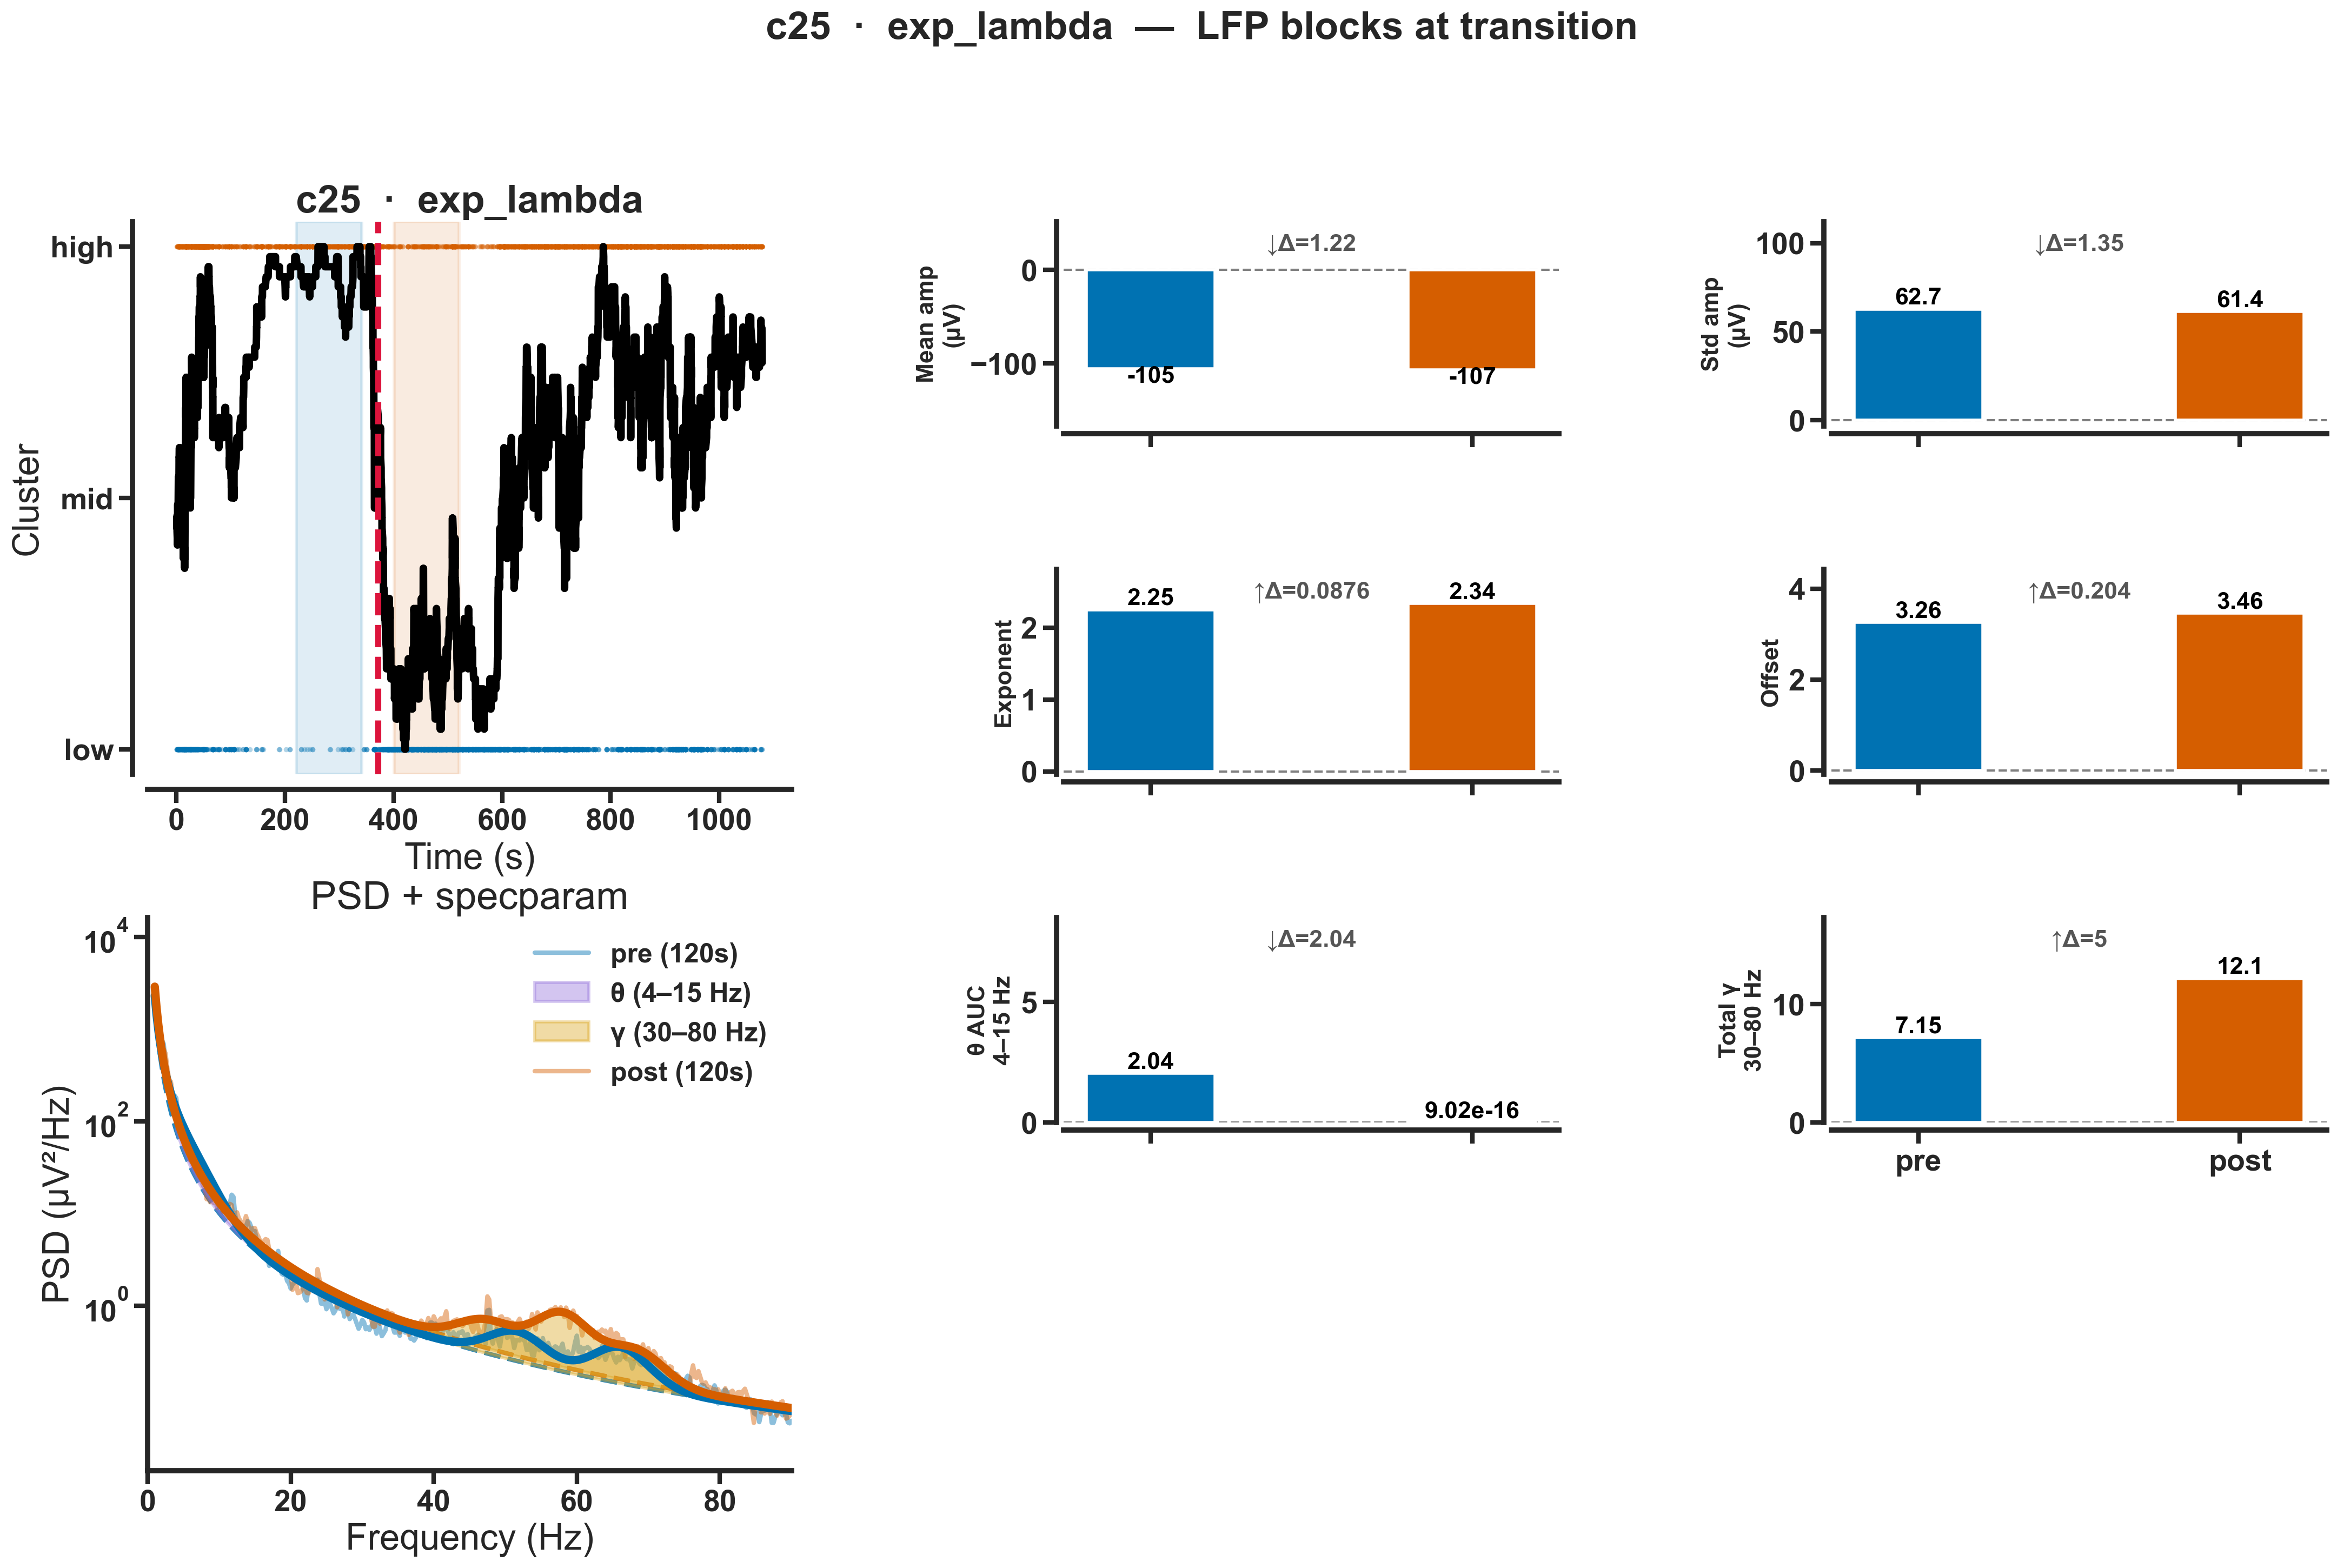


=== c25 | peak_width ===
  pre         R²=0.990  exp=2.209  θ=2.3889  sγ=3.3764  hγ=3.7145  totγ=7.0909  peaks=[CF=4.0Hz PW=0.296, CF=67.0Hz PW=0.381]
  post        R²=0.988  exp=2.311  θ=0.0000  sγ=7.8025  hγ=5.0594  totγ=12.8618  peaks=[CF=57.5Hz PW=0.612]


/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:5422: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  _bar_axes[1].legend(fontsize=13, frameon=False, loc='upper right')
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:5426: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=2.5, w_pad=2.0, h_pad=2.0)


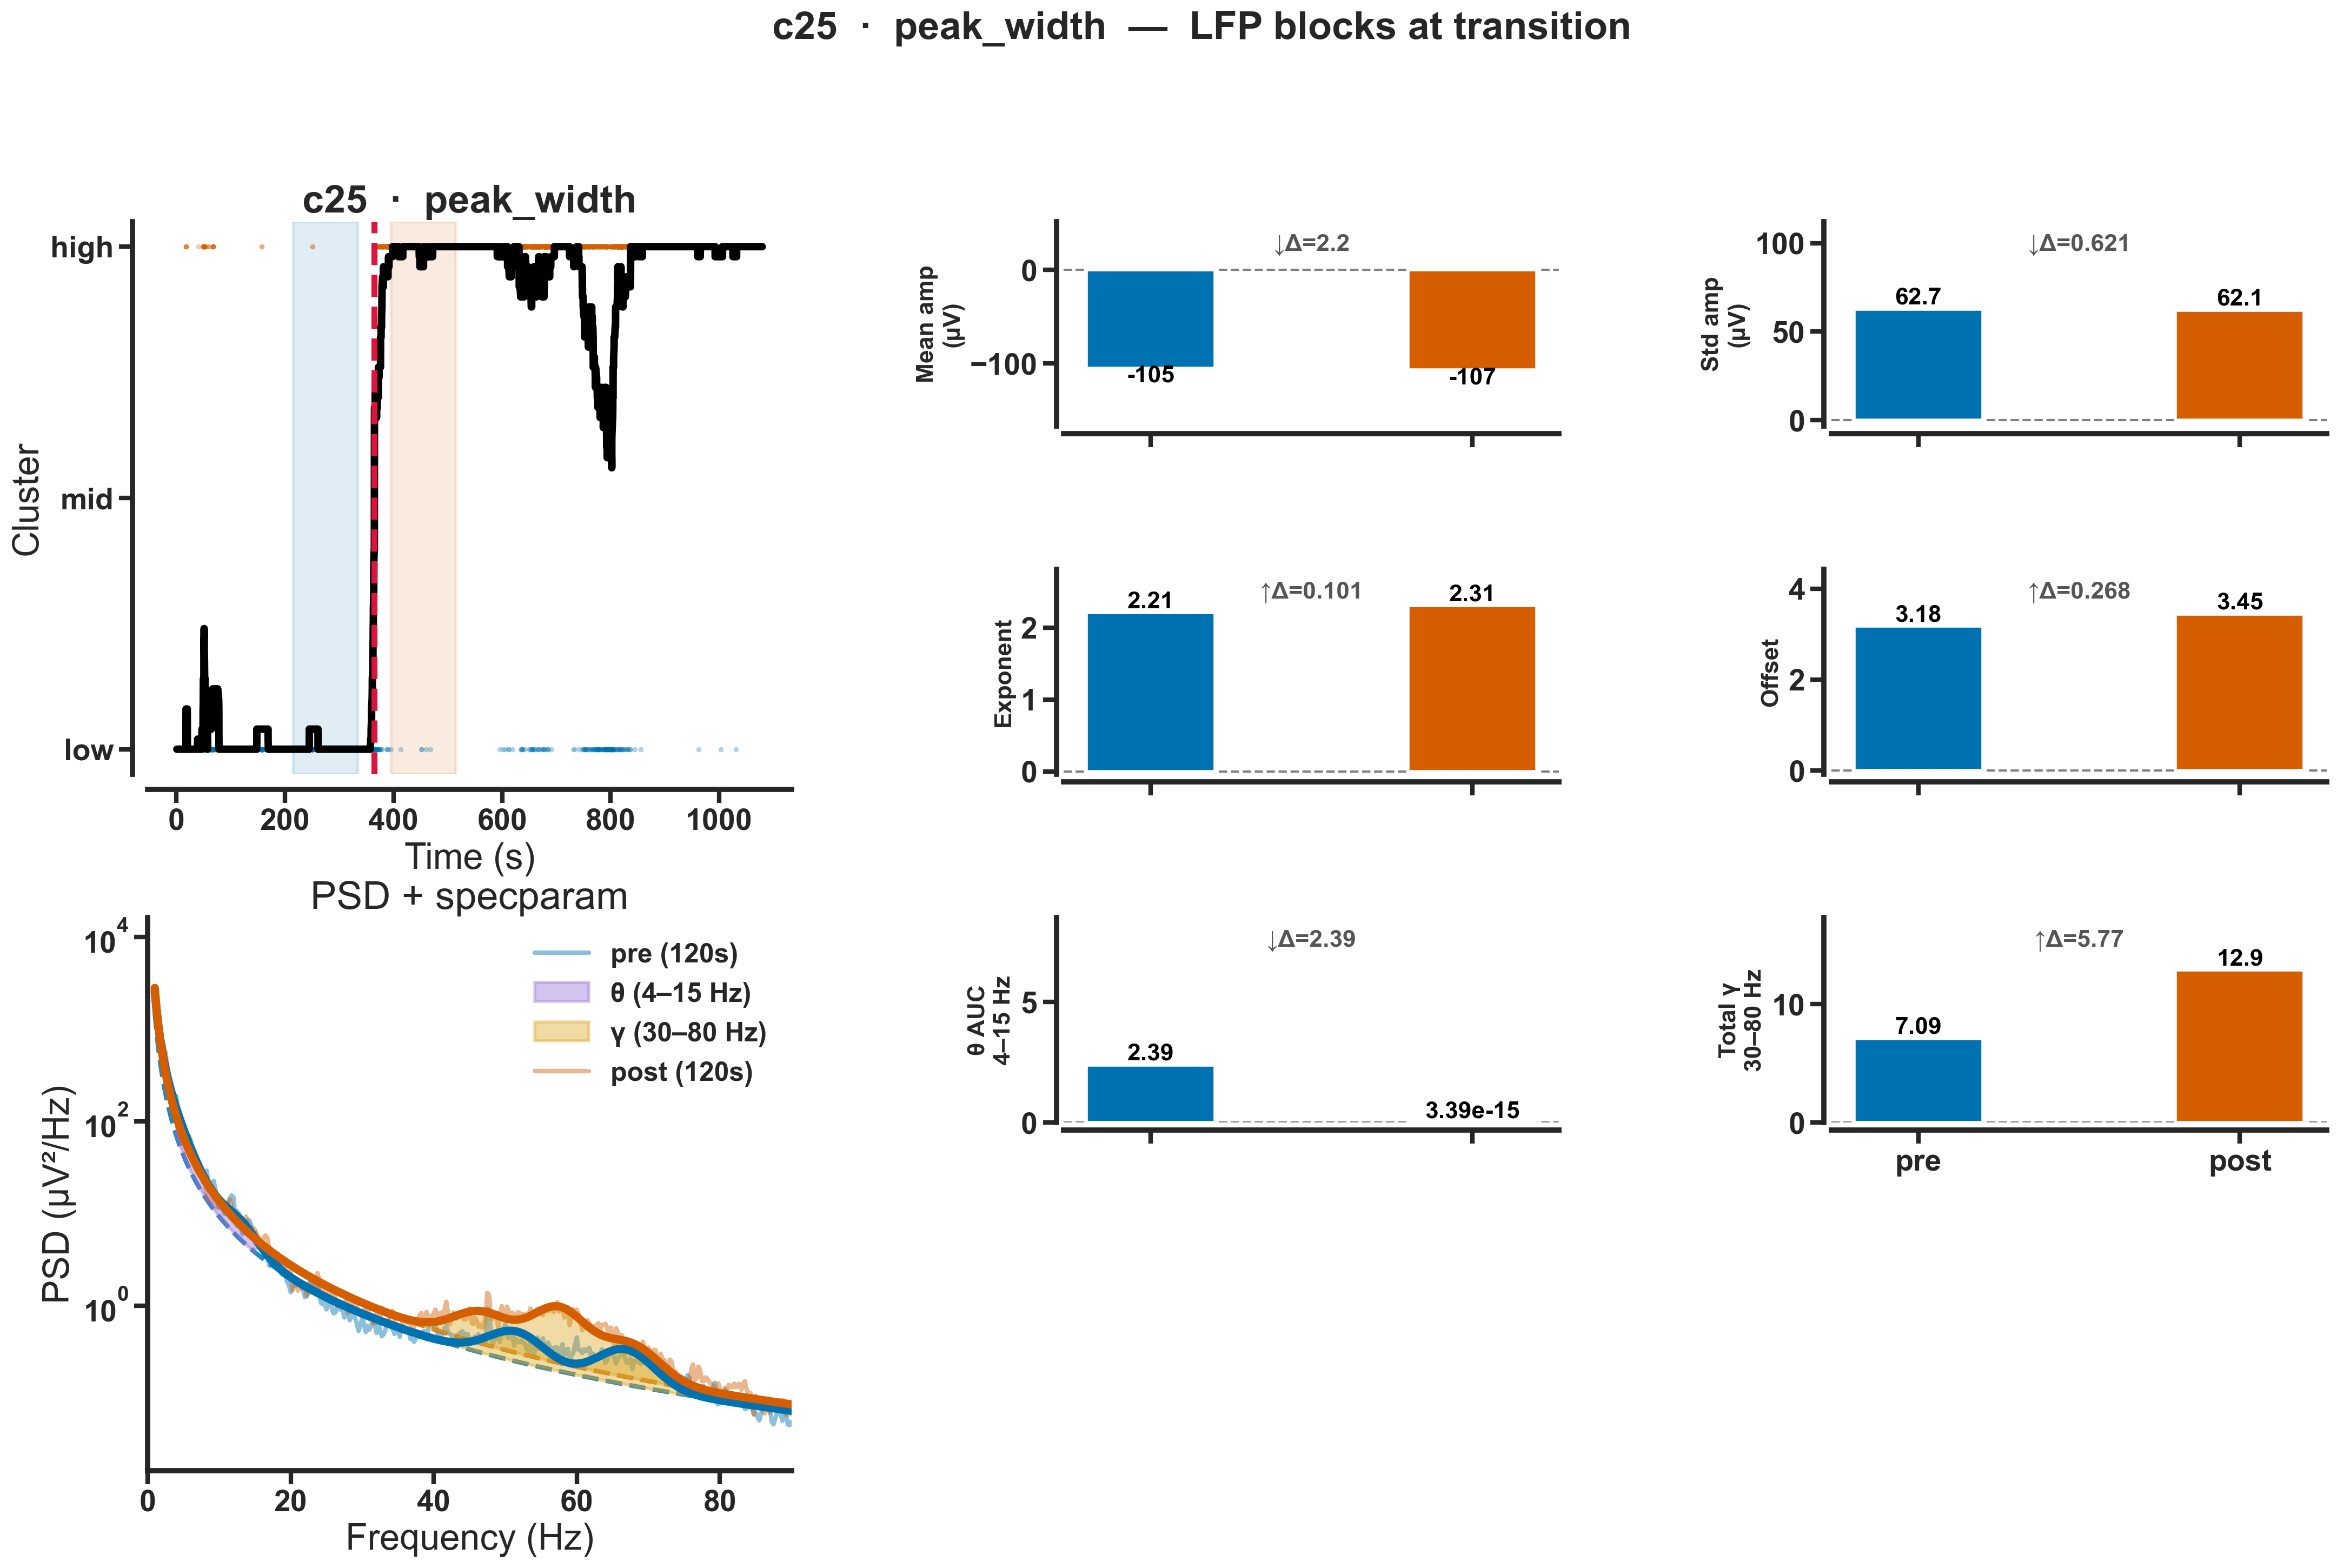


=== c35 | peak_width ===
  pre         R²=0.986  exp=2.623  θ=0.0000  sγ=5.4227  hγ=1.8658  totγ=7.2884  peaks=[CF=56.8Hz PW=0.322]
  post        R²=0.984  exp=2.535  θ=3.6103  sγ=3.0081  hγ=0.0010  totγ=3.0090  peaks=[CF=6.0Hz PW=0.504]


/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:5422: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  _bar_axes[1].legend(fontsize=13, frameon=False, loc='upper right')
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:5426: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=2.5, w_pad=2.0, h_pad=2.0)


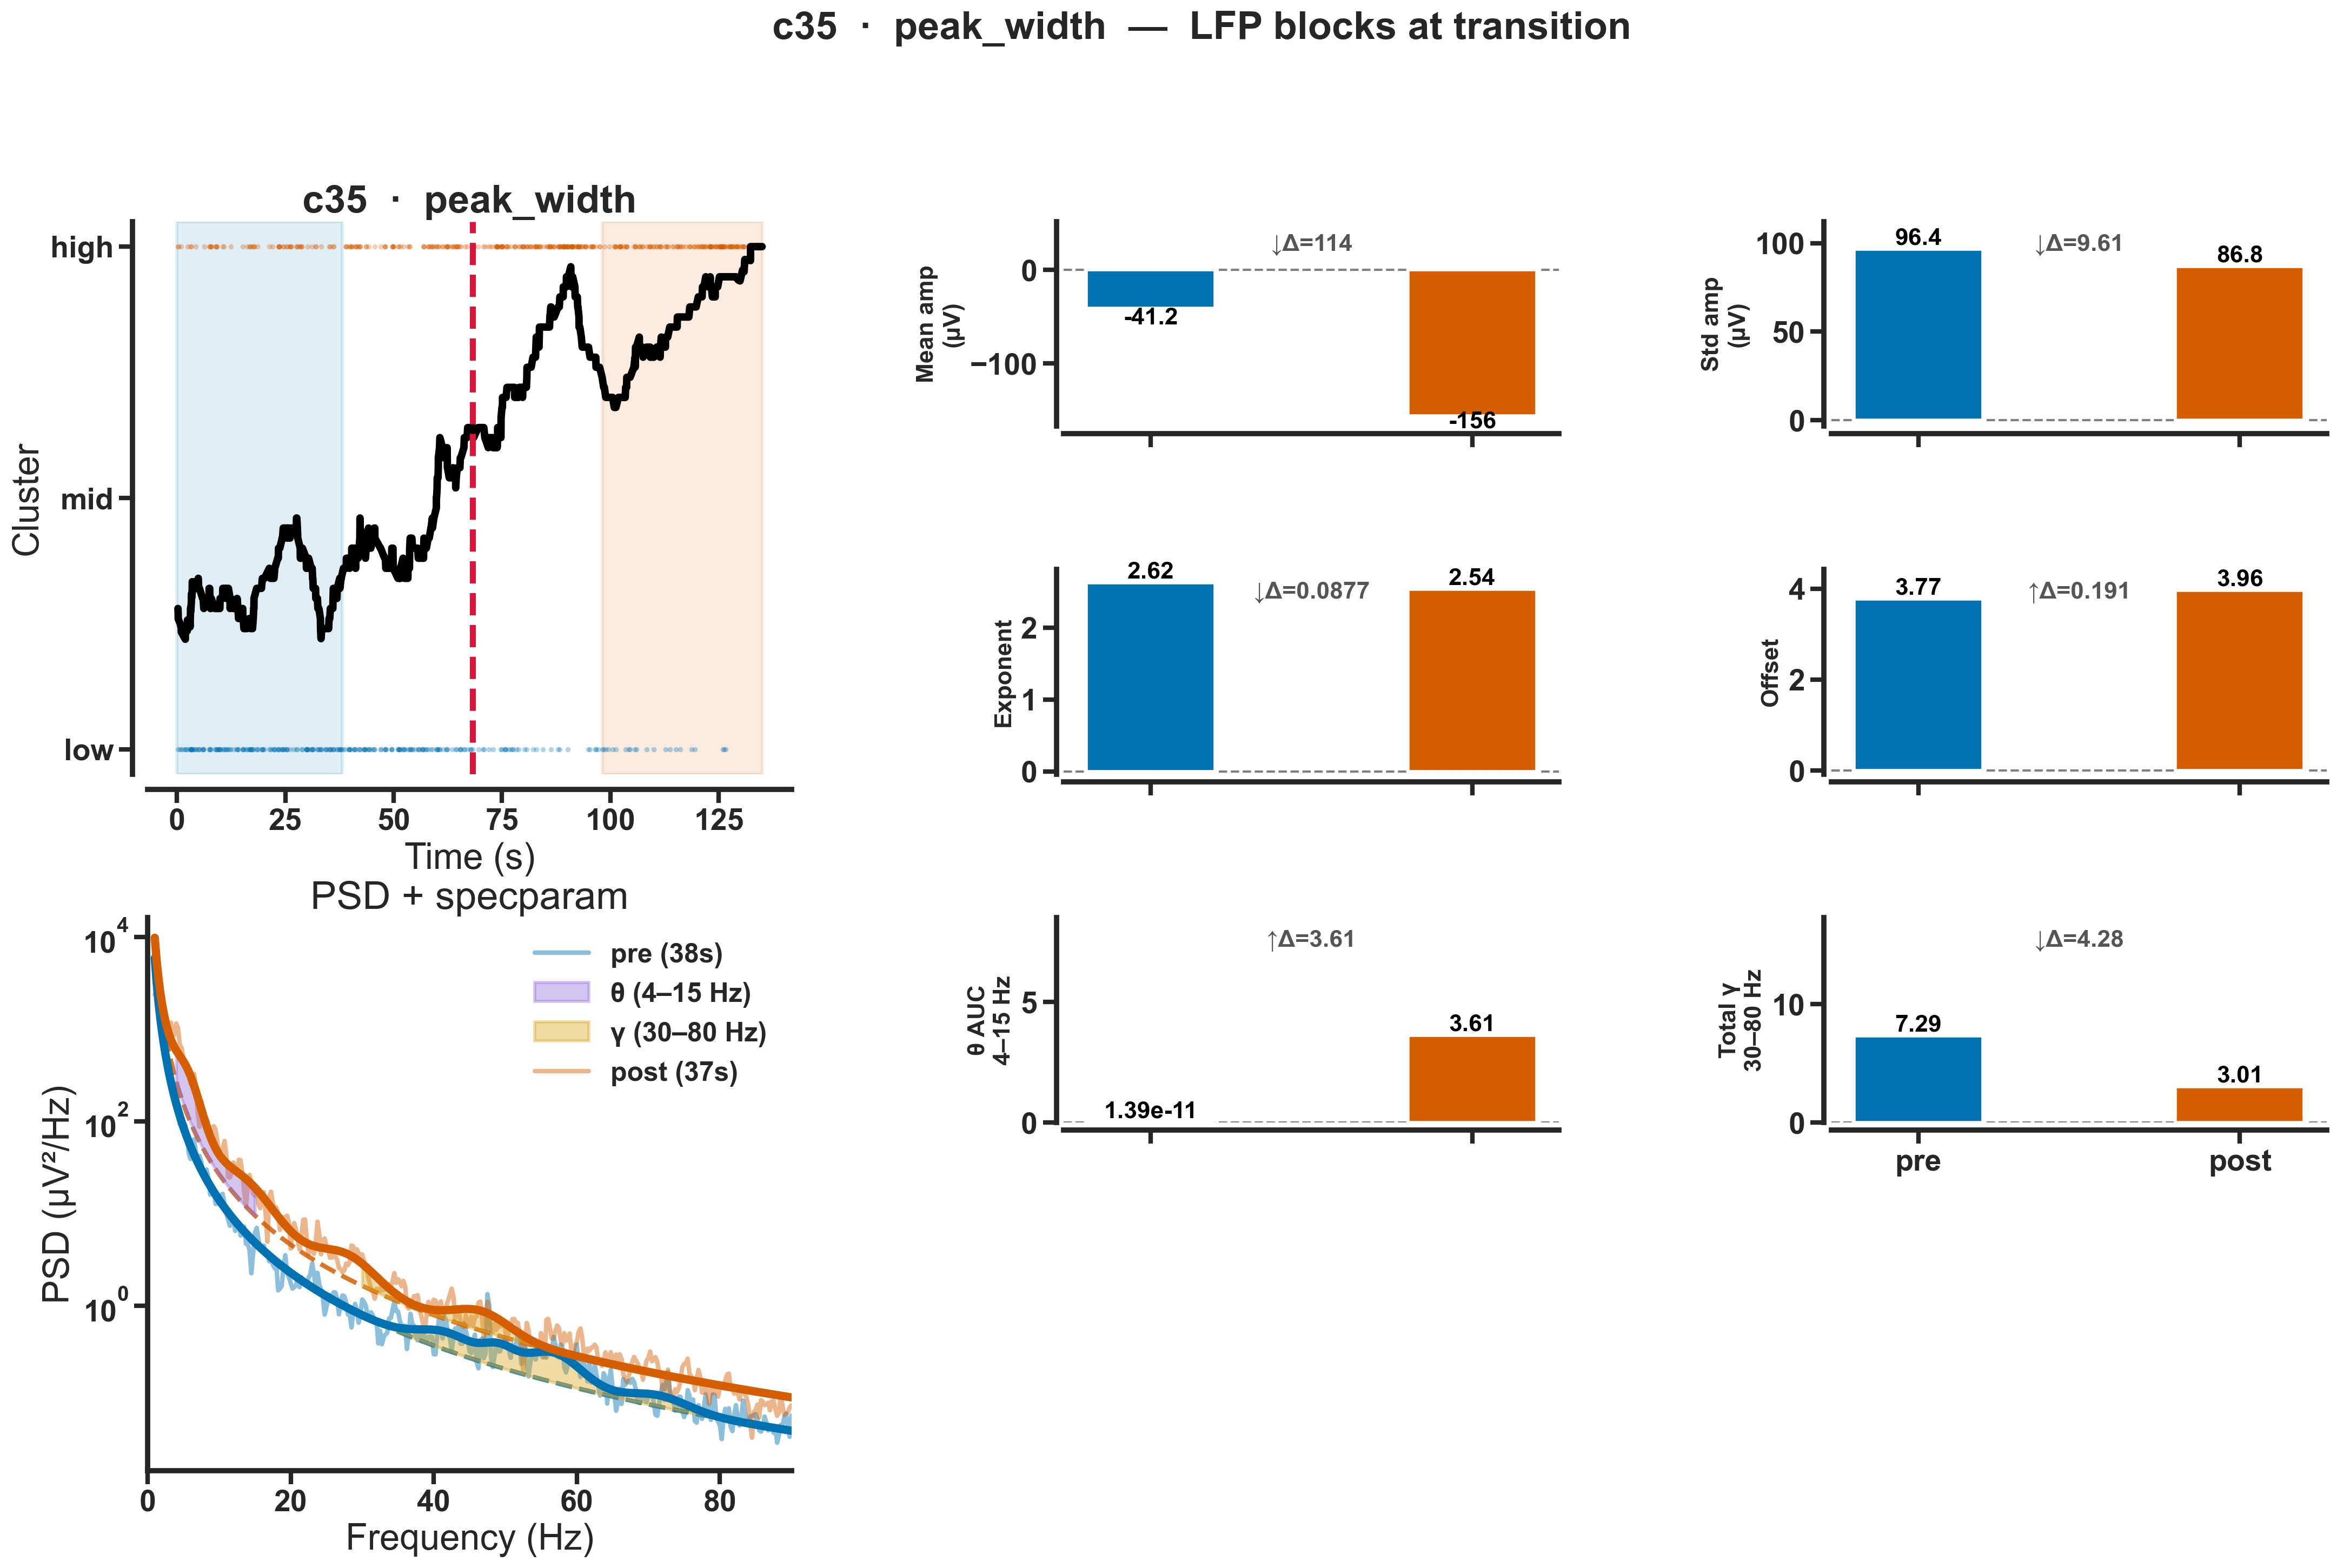

In [6]:
# Panel B: exemplar cells — top 4 transitions by |sign-corrected Δ total gamma AUC|
_BAR_KEYS = ['mean_amp', 'std_amp', 'exponent', 'offset', 'theta_auc', 'total_gamma_auc']

top_pairs = set(df_top.head(4)[['cell_id','feat','t_idx']].itertuples(index=False, name=None))

peri_top = {k: v for k, v in peri_results.items() if (k[0], k[1], k[2]) in top_pairs}
df_trans_top = df_transitions[
    df_transitions.apply(
        lambda r: (r.cell_id, r.spike_feature, int(r.transition_index)) in top_pairs, axis=1)
]

plot_lfp_block_comparison(
    peri_top, df_trans_top, CLUSTER_PKL_DIR,
    rolling_n=50,
    bar_keys=_BAR_KEYS,
)
plt.show()

**Supplementary Figure X. LFP spectral changes associated with within-neuron spike cluster transitions.**

(A) ...

(B) ...